# Student Academic Performance Analysis

## Objective

The objective of this project is to analyze factors that influence student academic performance and identify relationships between GPA and variables such as study time, attendance, parental support, tutoring, sports participation, music involvement, and volunteering activities.

## Importing necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Reading the data

In [2]:
df = pd.read_csv("data/student_performance_data.csv")
df

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2387,3388,18,1,0,3,10.680555,2,0,4,1,0,0,0,3.455509,0.0
2388,3389,17,0,0,1,7.583217,4,1,4,0,1,0,0,3.279150,4.0
2389,3390,16,1,0,2,6.805500,20,0,2,0,0,0,1,1.142333,2.0
2390,3391,16,1,1,0,12.416653,17,0,2,0,1,1,0,1.803297,1.0


## Exploring the data

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB
None


## Exploring GPA field

In [4]:
print(df["GPA"].describe())

count    2392.000000
mean        1.906186
std         0.915156
min         0.000000
25%         1.174803
50%         1.893393
75%         2.622216
max         4.000000
Name: GPA, dtype: float64


## Top 10 students having highest GPA

In [5]:
df.sort_values(by="GPA", ascending=False).head(10)

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
44,1045,18,1,0,1,18.921512,1,1,3,1,1,0,0,4.000000,0.0
442,1443,15,0,0,2,19.424398,0,0,3,0,1,1,1,4.000000,0.0
2028,3029,16,1,0,0,18.656924,0,1,4,1,0,0,1,4.000000,0.0
1919,2920,15,0,3,1,17.442121,1,1,1,1,1,0,0,4.000000,0.0
1705,2706,18,1,0,2,8.858282,0,1,4,1,0,0,0,4.000000,0.0
1278,2279,15,1,0,2,18.899696,3,1,3,1,1,0,0,4.000000,0.0
2319,3320,17,0,0,2,9.285447,0,0,4,1,0,1,1,4.000000,3.0
1260,2261,17,1,2,2,9.001905,2,1,3,1,1,0,0,3.984674,0.0
2354,3355,16,1,0,2,1.565490,4,1,4,1,1,0,0,3.979421,4.0
1900,2901,18,1,1,2,15.683744,1,1,4,0,1,0,0,3.951460,0.0


## Q1 : Does More Study Time Lead To Higher GPA?

In [6]:
df["StudyGroup"] = pd.cut(
    df["StudyTimeWeekly"],
    bins=[0, 5, 10, 20, 25],
    labels=["Low", "Medium", "High", "VeryHigh"]
)
# print(df["StudyGroup"].head(10))

print(df.groupby("StudyGroup", observed=True)["GPA"].mean())

StudyGroup
Low       1.691647
Medium    1.849145
High      2.048585
Name: GPA, dtype: float64


## Conclusion : 
The analysis indicates a positive relationship between weekly study time and GPA. Students who dedicate more hours to studying generally achieve better academic results.


## Q2 : Do Absences Affect GPA?

In [7]:
corr = df["Absences"].corr(df["GPA"])
print("\nCorrelation of Absences and GPA : ",corr)


Correlation of Absences and GPA :  -0.9193135764208644


## Conclusion :
Absences show a strong negative relationship with GPA. Students with higher numbers of absences tend to have significantly lower academic performance.


## Q3 : Does Parental Education Affect Student's Performance?

In [8]:
print(df.groupby("ParentalEducation")["GPA"].mean())

ParentalEducation
0    1.893045
1    1.944022
2    1.929881
3    1.809082
4    1.815812
Name: GPA, dtype: float64


## Conclusion : 
The differences in GPA across parental education levels are relatively small. While parental education may have some influence on academic outcomes, the data suggests that other factors such as study habits, attendance, and parental support may have a more noticeable impact on student performance.


## Q4 : Does Parental Support Affect Student's GPA?

In [9]:
print(df.groupby("ParentalSupport")["GPA"].mean())

ParentalSupport
0    1.540128
1    1.755700
2    1.884246
3    2.042409
4    2.191545
Name: GPA, dtype: float64


## Conclusion : 
The results show that GPA tends to increase as parental support increases. Students who receive stronger support from their families generally perform better academically.


## Q5 : Do Students Who Play Sports Perform Better Academically?

In [10]:
print(df.groupby("Sports")["GPA"].mean())

Sports
0    1.871240
1    1.986381
Name: GPA, dtype: float64


## Conclusion : 
Students who participate in sports have a slightly higher average GPA than those who do not. Although the difference is not large, the results suggest that involvement in sports may contribute positively to academic performance, possibly through improved discipline, time management, and overall well-being.


## Q6 : Does Participation in Music Affect GPA?

In [11]:
print(df.groupby("Music")["GPA"].mean())

Music
0    1.872969
1    2.041664
Name: GPA, dtype: float64


## Conclusion : 
Students involved in music activities show a marginally higher average GPA compared to non-participants. While the effect appears modest, participation in music may help develop skills such as concentration, creativity, and persistence that can support academic success.


## Q7 : Does Volunteering impact GPA?

In [12]:
print(df.groupby("Volunteering")["GPA"].mean())

Volunteering
0    1.904899
1    1.913089
Name: GPA, dtype: float64


## Conclusion : 
Students who participate in volunteering activities tend to achieve slightly better academic results. This may indicate that students who engage in community activities often possess qualities such as responsibility, commitment, and effective time management, which can also benefit their studies.


## Q8 : Do Students Receiving Tutoring Perform Better?

In [13]:
print(df.groupby("Tutoring")["GPA"].mean())

Tutoring
0    1.818968
1    2.108325
Name: GPA, dtype: float64


## Conclusion : 
Students receiving tutoring have a higher average GPA compared to those who do not receive tutoring. This suggests that additional academic support may help students better understand course material and improve their overall performance.


## Visualization : 

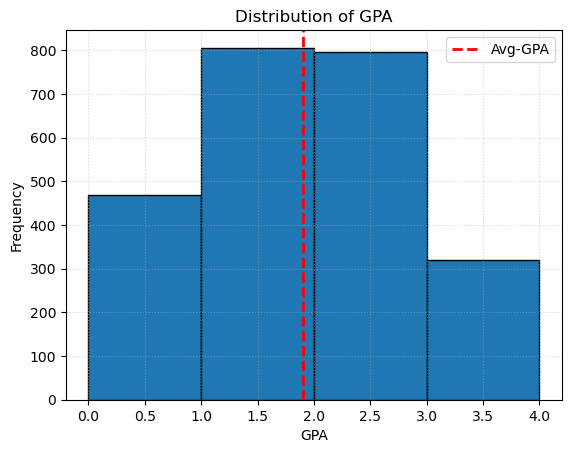

In [14]:
plt.hist(df["GPA"], bins=[0, 1, 2, 3, 4], edgecolor="black")
plt.title("Distribution of GPA")
plt.xlabel("GPA")
plt.ylabel("Frequency")
plt.axvline(np.mean(df["GPA"]), color="red", linestyle="--", linewidth=2, label="Avg-GPA")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.5)
plt.show()

## Conclusion : 
The GPA distribution shows that most students are concentrated around the middle GPA range, while very low and very high GPAs are less common. This suggests that the majority of students achieve average academic performance, with only a small proportion performing at the extreme ends.


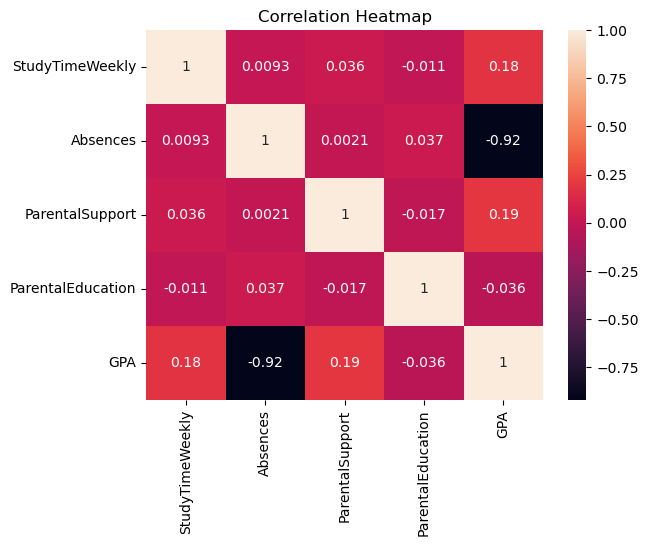

In [15]:
cols = df[["StudyTimeWeekly", "Absences", "ParentalSupport", "ParentalEducation", "GPA"]]
corr = cols.corr()
# print(corr)

sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

## Conclusion :
The correlation analysis reveals that absences have the strongest relationship with GPA, with a very strong negative correlation of -0.92. This indicates that students with higher numbers of absences tend to achieve significantly lower GPAs. Study time and parental support show weak positive correlations with GPA (0.18 and 0.19 respectively), suggesting that increased study hours and greater parental support are associated with slightly better academic performance. Parental education exhibits almost no correlation with GPA (-0.04), indicating little to no relationship within this dataset.


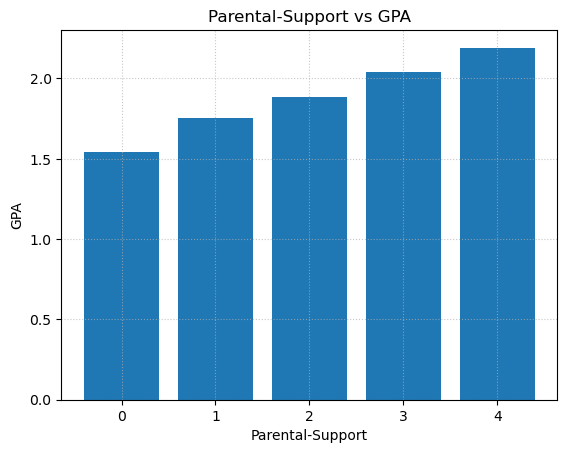

In [16]:
avg = df.groupby("ParentalSupport")["GPA"].mean()
plt.bar(avg.index, avg.values)
plt.title("Parental-Support vs GPA")
plt.xlabel("Parental-Support")
plt.ylabel("GPA")
plt.grid(True, linestyle=":", alpha=0.7)
plt.show()

## Conclusion :
The chart shows a gradual increase in average GPA as parental support levels rise. Students receiving stronger parental support generally perform better academically, suggesting that encouragement and involvement from family members may positively influence educational outcomes.


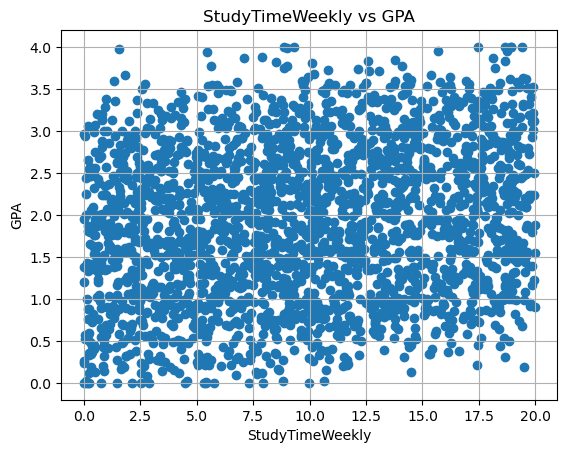

In [17]:
plt.scatter(df["StudyTimeWeekly"], df["GPA"])
# corr = df[["StudyTimeWeekly", "GPA"]].corr()
# print(corr)
plt.title("StudyTimeWeekly vs GPA")
plt.xlabel("StudyTimeWeekly")
plt.ylabel("GPA")
plt.grid(True)
plt.show()

## Conclusion :
The scatter plot reveals a positive relationship between study time and GPA. Although individual differences exist, students who spend more time studying generally tend to achieve better academic results. This suggests that consistent study habits may contribute positively to academic success.


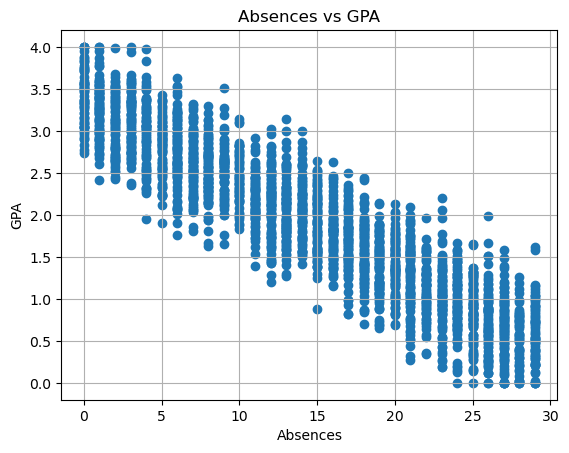

In [18]:
plt.scatter(df["Absences"], df["GPA"])
# corr = df[["Absences", "GPA"]].corr()
# print(corr)
plt.title("Absences vs GPA")
plt.xlabel("Absences")
plt.ylabel("GPA")
plt.grid(True)
plt.show()

## Conclusion :
The scatter plot shows a clear downward trend, indicating that students with more absences tend to have lower GPAs. The relationship appears relatively strong, suggesting that regular attendance may be one of the most important factors influencing academic performance.


# Key Findings

1. Absences have the strongest impact on GPA, showing a strong negative correlation (-0.92).

2. Students who study more generally achieve higher GPAs.

3. Higher parental support is associated with better academic performance.

4. Students receiving tutoring tend to perform better academically.

5. Sports, music, and volunteering show small positive associations with GPA.

6. Parental education shows little relationship with GPA in this dataset.